# Simple normalising flow: Gaussian to Gaussian in JAX

This notebook implements the analytic affine normalising flow shown in the slide above, then trains a second affine flow with SGD to learn the same map. 

As we saw (in this diagram here) the normalising flow maps from one distribution (blue) to another (red) that in practice we may not know analytically.

The base density (blue) is

$$z \sim \mathcal{N}(0, I),$$

and the affine push-forward $p_\phi(x)$ (red, where $\phi = \{\mu, A\}$) is

$$x = A z + \mu,$$

where $A A^T = \Sigma$. The resulting density is exactly

$$x \sim \mathcal{N}(\mu, \Sigma).$$

The inverse map and change-of-variables density are

$$z = A^{-1}(x - \mu), \qquad \log p_\phi(x) = \log p(z) - \log |\det A|.$$

![Analytic normalising flow example](analytic_flow_example.jpeg)


In [ ]:
try:
    import jax
    import jax.numpy as jnp
    import jax.random as jr
except ImportError:
    %pip install -q "jax[cpu]"
    import jax
    import jax.numpy as jnp
    import jax.random as jr

import matplotlib.pyplot as plt
import numpy as np

key = jr.key(7)

## Analytic affine flow

For a Gaussian-to-Gaussian normalising flow, one invertible affine transform is enough. Here `A` is the Cholesky factor of the target covariance, so it is triangular, invertible, and has a cheap log-determinant.

In [2]:
class AffineGaussianFlow:
    def __init__(self, mu, covariance):
        self.mu = jnp.asarray(mu, dtype=jnp.float32)
        self.covariance = jnp.asarray(covariance, dtype=jnp.float32)

        if self.covariance.shape != (self.mu.size, self.mu.size):
            raise ValueError("covariance must have shape (dim, dim)")

        self.dim = self.mu.size
        self.A = jnp.linalg.cholesky(self.covariance)
        self.log_abs_det_A = jnp.linalg.slogdet(self.A)[1]

    def forward(self, z):
        # Map from z -> x
        z = jnp.asarray(z, dtype=jnp.float32)
        return z @ self.A.T + self.mu

    def inverse(self, x):
        # Map from x -> z
        x = jnp.asarray(x, dtype=jnp.float32)
        return jnp.linalg.solve(self.A, (x - self.mu).T).T

    def base_log_prob(self, z):
        z = jnp.asarray(z, dtype=jnp.float32)
        return -0.5 * (self.dim * jnp.log(2 * jnp.pi) + jnp.sum(z**2, axis=-1))

    def log_prob(self, x):
        z = self.inverse(x)
        return self.base_log_prob(z) - self.log_abs_det_A

    def sample(self, key, n):
        z = jr.normal(key, shape=(n, self.dim))
        x = self.forward(z)
        return x, z

## Choose a target Gaussian

The target has a non-zero mean and a non-isotropic covariance with correlation between the two coordinates.

In a more realistic SBI analysis we may not know this PDF e.g. we can't write down its mean (`mu`) and covariance (`Sigma`).

In [3]:
mu = jnp.array([4.2, -0.8], dtype=jnp.float32)
Sigma = jnp.array([
    [2.4, 1.0],
    [1.0, 0.9],
], dtype=jnp.float32)

analytic_flow = AffineGaussianFlow(mu, Sigma)

## Push samples through the analytic flow

In [4]:
n_samples = 6_000
key, sample_key = jr.split(key)
x, z = analytic_flow.sample(sample_key, n_samples)
z_recovered = analytic_flow.inverse(x)

## Compare flow density with the analytic Gaussian density

In [ ]:
def gaussian_log_prob(x, mu, covariance):
    x = jnp.asarray(x, dtype=jnp.float32)
    diff = x - mu
    precision = jnp.linalg.inv(covariance)
    mahalanobis = jnp.einsum("...i,ij,...j->...", diff, precision, diff)
    sign, log_det = jnp.linalg.slogdet(covariance)
    if sign <= 0:
        raise ValueError("covariance must be positive definite")
    return -0.5 * (mu.size * jnp.log(2 * jnp.pi) + log_det + mahalanobis)


key, test_key = jr.split(key)
test_noise = jr.normal(test_key, shape=(10, 2))
test_points = test_noise @ jnp.array([[1.5, 0.8], [0.0, 0.6]], dtype=jnp.float32).T + mu
flow_log_prob = analytic_flow.log_prob(test_points)
analytic_log_prob = gaussian_log_prob(test_points, mu, Sigma)

maximum |flow log p(x) - analytic log p(x)|: 4.7683716e-07


## Train the same affine flow with SGD

The learned flow has the same form, `x = A_theta z + mu_theta`, but we learn `A_theta` and `mu_theta` by maximum likelihood on samples from the target Gaussian. 

This is close to the SGD training of a "normal" neural network that we saw mapping data to parameters $x\rightarrow\theta$.

To keep `A_theta` invertible during training, it is parameterised as a lower-triangular matrix with positive diagonal entries.

In [6]:
def build_trained_A(params):
    diag = jax.nn.softplus(params["raw_diag"]) + 1e-4
    return jnp.array([
        [diag[0], 0.0],
        [params["offdiag"], diag[1]],
    ], dtype=jnp.float32)


def trained_base_log_prob(z):
    return -0.5 * (2 * jnp.log(2 * jnp.pi) + jnp.sum(z**2, axis=-1))


def trained_forward(params, z):
    A = build_trained_A(params)
    return z @ A.T + params["mu"]


def trained_inverse(params, x):
    A = build_trained_A(params)
    return jnp.linalg.solve(A, (x - params["mu"]).T).T


def trained_log_prob(params, x):
    A = build_trained_A(params)
    z = trained_inverse(params, x)
    return trained_base_log_prob(z) - jnp.linalg.slogdet(A)[1]


def negative_log_likelihood(params, batch):
    return -jnp.mean(trained_log_prob(params, batch))


@jax.jit
def sgd_step(params, batch, learning_rate):
    loss, grads = jax.value_and_grad(negative_log_likelihood)(params, batch)
    params = jax.tree_util.tree_map(lambda p, g: p - learning_rate * g, params, grads)
    return params, loss

In [7]:
n_train = 20_000
batch_size = 512
n_steps = 2_500
learning_rate = 3e-2

key, train_key = jr.split(key)
target_train_x, _ = analytic_flow.sample(train_key, n_train)
true_train_nll = float(-jnp.mean(analytic_flow.log_prob(target_train_x)))

trained_params = {
    "mu": jnp.array([0.0, 0.0], dtype=jnp.float32),
    "raw_diag": jnp.array([0.0, 0.0], dtype=jnp.float32),
    "offdiag": jnp.array(0.0, dtype=jnp.float32),
}

loss_history = []
for step in range(n_steps):
    key, batch_key = jr.split(key)
    batch_idx = jr.randint(batch_key, shape=(batch_size,), minval=0, maxval=n_train)
    batch = target_train_x[batch_idx]
    trained_params, loss = sgd_step(trained_params, batch, learning_rate)

    if step % 25 == 0 or step == n_steps - 1:
        loss_history.append((step, float(loss)))

trained_A = build_trained_A(trained_params)
trained_Sigma = trained_A @ trained_A.T

## Check the trained flow

In [8]:
key, trained_sample_key = jr.split(key)
trained_z = jr.normal(trained_sample_key, shape=(n_samples, 2))
trained_x = trained_forward(trained_params, trained_z)

trained_test_log_prob = trained_log_prob(trained_params, test_points)
print("maximum |trained log p(x) - analytic log p(x)| on test points:", jnp.max(jnp.abs(trained_test_log_prob - analytic_log_prob)))
print("trained sample mean:", jnp.mean(trained_x, axis=0))
print("trained sample covariance:\n", jnp.cov(trained_x.T))

maximum |trained log p(x) - analytic log p(x)| on test points: 0.086853504
trained sample mean: [ 4.212982  -0.7754051]
trained sample covariance:
 [[2.4035368  0.9960691 ]
 [0.9960691  0.87879896]]


## Training curve and learned density

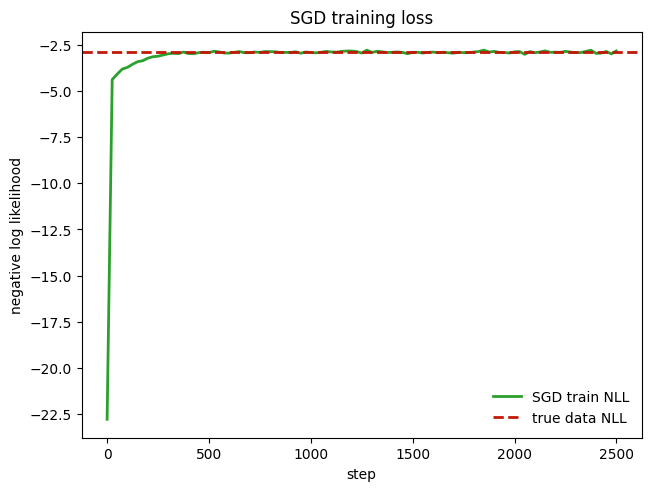

In [ ]:
loss_steps = np.array([item[0] for item in loss_history]) 
loss_values = -np.array([item[1] for item in loss_history]) # Let's show log-likelihood, not its negative

fig, axes = plt.subplots(1, 1, constrained_layout=True)

axes.plot(loss_steps, loss_values, color="#2ca02c", lw=2, label="SGD train NLL")
axes.axhline(-true_train_nll, color="#c21807", lw=2, ls="--", label="true data NLL")
axes.set_title("SGD training loss")
axes.set_xlabel("step")
axes.set_ylabel("negative log likelihood")
axes.legend(frameon=False)

plt.show()

## Single-space view

The same ingredients can also be drawn on one set of axes. Blue shows the base density in `z`-space, red shows the analytic pushed-forward density, green dashed contours show the SGD-trained pushed-forward density, and grey line segments show how selected samples move under the analytic affine flow.

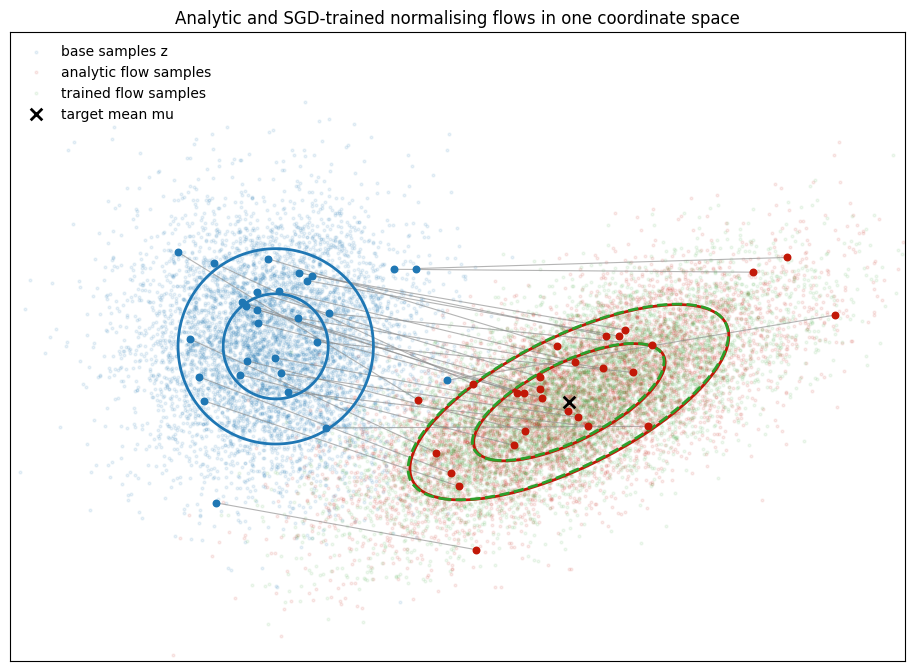

In [11]:
def density_grid(log_prob_fn, xlim, ylim, n=220):
    xs = jnp.linspace(xlim[0], xlim[1], n)
    ys = jnp.linspace(ylim[0], ylim[1], n)
    xx, yy = jnp.meshgrid(xs, ys)
    points = jnp.column_stack([xx.ravel(), yy.ravel()])
    density = jnp.exp(log_prob_fn(points)).reshape(xx.shape)
    return np.asarray(xx), np.asarray(yy), np.asarray(density)


base_xx, base_yy, base_density = density_grid(
    analytic_flow.base_log_prob,
    xlim=(-3.2, 3.2),
    ylim=(-3.2, 3.2),
)
target_xx, target_yy, target_density = density_grid(
    analytic_flow.log_prob,
    xlim=(-2.0, 8.5),
    ylim=(-4.0, 2.8),
)
trained_xx, trained_yy, trained_density = density_grid(
    lambda points: trained_log_prob(trained_params, points),
    xlim=(-2.0, 8.5),
    ylim=(-4.0, 2.8),
)

z_np = np.asarray(z)
x_np = np.asarray(x)
trained_x_np = np.asarray(trained_x)

fig, ax = plt.subplots(figsize=(9.2, 6.6), constrained_layout=True)

ax.scatter(z_np[:, 0], z_np[:, 1], s=4, alpha=0.09, color="#1f77b4", label="base samples z")
ax.contour(base_xx, base_yy, base_density, levels=2, colors="#1f77b4", linewidths=2)

ax.scatter(x_np[:, 0], x_np[:, 1], s=4, alpha=0.08, color="#c21807", label="analytic flow samples")
ax.contour(target_xx, target_yy, target_density, levels=2, colors="#c21807", linewidths=2)

ax.scatter(trained_x_np[:, 0], trained_x_np[:, 1], s=4, alpha=0.07, color="#2ca02c", label="trained flow samples")
ax.contour(trained_xx, trained_yy, trained_density, levels=2, colors="#2ca02c", linewidths=2, linestyles="--")

overlay_subset = np.linspace(0, n_samples - 1, 28, dtype=int)
for idx in overlay_subset:
    ax.plot(
        [z_np[idx, 0], x_np[idx, 0]],
        [z_np[idx, 1], x_np[idx, 1]],
        color="0.55",
        lw=0.8,
        alpha=0.65,
        zorder=1,
    )

ax.scatter(z_np[overlay_subset, 0], z_np[overlay_subset, 1], s=22, color="#1f77b4", zorder=3)
ax.scatter(x_np[overlay_subset, 0], x_np[overlay_subset, 1], s=22, color="#c21807", zorder=3)
ax.scatter(*np.asarray(mu), s=70, marker="x", color="black", linewidths=2, label="target mean mu", zorder=4)

ax.set_title("Analytic and SGD-trained normalising flows in one coordinate space")
ax.set_xlim(-3.8, 9.0)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(frameon=False, loc="upper left")

plt.show()